# 03 — Baseline e protocolo experimental

**Entregável E4 / Blocos B3 e B4** (IBM8924 — AC de Projeto, Grupo 1).

Usa o dataset e o split 70/15/15 (sem vazamento espacial) gerados por `01_dados.ipynb`.
Treina e compara dois modelos:

1. **Baseline trivial** — classe majoritária (`DummyClassifier`).
2. **Baseline principal** — regressão logística sobre atributos agregados por patch
   (médias/desvios por banda + NDVI/GNDVI).

Avalia com acurácia, F1 macro e matriz de confusão no conjunto de teste, e analisa
manualmente pelo menos 4 erros do modelo principal.

Rode `01_dados.ipynb` (e, opcionalmente, `02_caracterizacao.ipynb`) antes deste notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
)

from dataset_utils import load_dataset, aggregate_features_batch, rgb_composite, FEATURE_NAMES

SEED = 42
CLASS_NAMES = {0: 'Baixo vigor', 1: 'Médio vigor', 2: 'Alto vigor'}

data = load_dataset('../data/processed/s2_patches.npz')
X_img, y, split = data['X'], data['y'], data['split']

print('Recortes por partição:', dict(zip(*np.unique(split, return_counts=True))))


Recortes por partição: {'test': np.int64(262), 'train': np.int64(1252), 'val': np.int64(286)}


## 1. Atributos agregados e split

Cada patch `(64, 64, 6)` vira um vetor de 15 atributos (`FEATURE_NAMES`): média e
desvio-padrão de cada uma das 6 bandas, mais média/desvio do NDVI e média do GNDVI.
Reaproveitamos o split feito em `01_dados.ipynb` por bloco espacial — não refazemos
a divisão aqui.

In [2]:
X_feat = aggregate_features_batch(X_img)
print('X_feat:', X_feat.shape, '| atributos:', FEATURE_NAMES)

train_mask, val_mask, test_mask = split == 'train', split == 'val', split == 'test'

X_train, y_train = X_feat[train_mask], y[train_mask]
X_val, y_val = X_feat[val_mask], y[val_mask]
X_test, y_test = X_feat[test_mask], y[test_mask]

print(f'Train: {len(y_train)}  Val: {len(y_val)}  Test: {len(y_test)}')


X_feat: (1800, 15) | atributos: ['B2_mean', 'B2_std', 'B3_mean', 'B3_std', 'B4_mean', 'B4_std', 'B8_mean', 'B8_std', 'B11_mean', 'B11_std', 'B12_mean', 'B12_std', 'NDVI_mean', 'NDVI_std', 'GNDVI_mean']
Train: 1252  Val: 286  Test: 262


## 2. Baseline trivial — classe majoritária

In [3]:
trivial = DummyClassifier(strategy='most_frequent', random_state=SEED)
trivial.fit(X_train, y_train)
y_pred_trivial = trivial.predict(X_test)

acc_trivial = accuracy_score(y_test, y_pred_trivial)
f1_trivial = f1_score(y_test, y_pred_trivial, average='macro', zero_division=0)
print(f'Baseline trivial -- acurácia: {acc_trivial:.3f} | F1 macro: {f1_trivial:.3f}')


Baseline trivial -- acurácia: 0.248 | F1 macro: 0.133


## 3. Baseline principal — regressão logística sobre atributos agregados

**Hiperparâmetros:** `StandardScaler` (média/desvio ajustados só no treino) seguido de
`LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)` — demais
hiperparâmetros do scikit-learn na versão padrão (`C=1.0`, regularização L2, solver
`lbfgs`). Escolhido em vez de uma CNN pequena porque o time já valida domínio de deep
learning no pipeline avançado (LSTM sobre embeddings AlphaEarth, ver README) e o
enunciado aceita ambas as opções para o baseline mínimo.

In [4]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=SEED)
logreg.fit(X_train_s, y_train)

y_pred_val = logreg.predict(X_val_s)
print('Validação -- acurácia:', accuracy_score(y_val, y_pred_val),
      '| F1 macro:', f1_score(y_val, y_pred_val, average='macro', zero_division=0))


Validação -- acurácia: 0.36363636363636365 | F1 macro: 0.25016453486708445


Regressão logística -- acurácia: 0.275 | F1 macro: 0.206

              precision    recall  f1-score   support

 Baixo vigor       0.26      0.91      0.41        65
 Médio vigor       0.34      0.15      0.21        86
  Alto vigor       0.00      0.00      0.00       111

    accuracy                           0.27       262
   macro avg       0.20      0.35      0.21       262
weighted avg       0.18      0.27      0.17       262



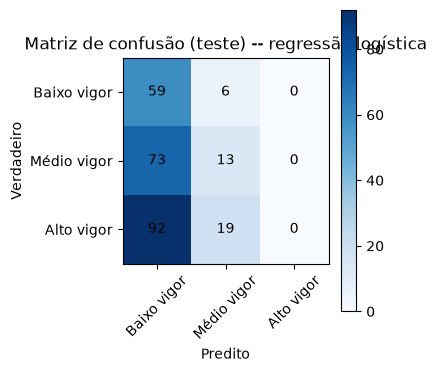

In [5]:
y_pred_test = logreg.predict(X_test_s)

acc_main = accuracy_score(y_test, y_pred_test)
f1_main = f1_score(y_test, y_pred_test, average='macro', zero_division=0)

print(f'Regressão logística -- acurácia: {acc_main:.3f} | F1 macro: {f1_main:.3f}\n')
print(classification_report(
    y_test, y_pred_test,
    target_names=[CLASS_NAMES[c] for c in sorted(CLASS_NAMES)],
    zero_division=0,
))

cm = confusion_matrix(y_test, y_pred_test, labels=sorted(CLASS_NAMES))
plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Matriz de confusão (teste) -- regressão logística')
plt.colorbar()
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.xticks(range(len(CLASS_NAMES)), [CLASS_NAMES[c] for c in sorted(CLASS_NAMES)], rotation=45)
plt.yticks(range(len(CLASS_NAMES)), [CLASS_NAMES[c] for c in sorted(CLASS_NAMES)])
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.tight_layout()
plt.show()


Na Matriz de Confusão podemos ver que a Regressão Logistica não preveu nenhum valor como alto vigor, e preveu majoritariamente so com baixo vigor, que mostra que a logistica sofre com underfitting por ser extremamente raiz.

## 4. Comparação obrigatória: trivial vs. principal

In [6]:
import pandas as pd

comparison = pd.DataFrame({
    'modelo': ['Baseline trivial (classe majoritária)', 'Regressão logística (atributos agregados)'],
    'acuracia': [acc_trivial, acc_main],
    'f1_macro': [f1_trivial, f1_main],
})
comparison


,modelo,acuracia,f1_macro
0,Baseline trivial (classe majoritária),0.248092,0.132518
1,Regressão logística (atributos agregados),0.274809,0.205994


Podemos ver que o modelo de regressão logistica tem um acuracia de 0.20 e f1_macro de 0.27 respectivamente em comparação com o baseline trivial com acuracia de 0.24 e f1_macro de 0.13. Estes resultados são pessimos para a regressão logistica e sendo que so tem uma acuracia maior de 4%, com valores poucos melhores em recall e precision.

## 5. Análise de erros (≥4 exemplos)

Mostra recortes classificados incorretamente pela regressão logística no conjunto de
teste, com o rótulo verdadeiro e o predito.

190 erros no conjunto de teste; mostrando 4.


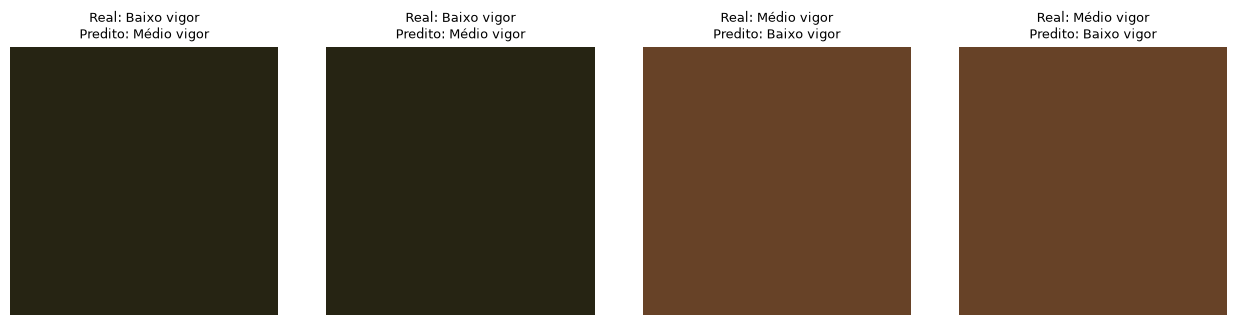

In [7]:
test_indices = np.where(test_mask)[0]
wrong = test_indices[y_pred_test != y_test]

N_ERRORS = min(4, len(wrong))
print(f'{len(wrong)} erros no conjunto de teste; mostrando {N_ERRORS}.')

fig, axes = plt.subplots(1, max(N_ERRORS, 1), figsize=(3.2 * max(N_ERRORS, 1), 3.2))
if N_ERRORS == 1:
    axes = [axes]

for ax, idx in zip(axes, wrong[:N_ERRORS]):
    pos_in_test = np.where(test_indices == idx)[0][0]
    ax.imshow(rgb_composite(X_img[idx]))
    ax.set_title(f'Real: {CLASS_NAMES[y[idx]]}\nPredito: {CLASS_NAMES[y_pred_test[pos_in_test]]}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()


Podemos ver que nos 4 erros preditos quando tinho predição de vigor medio, o verdadeiro era vigor baixo. E quando era predito baixo vigor, o verdadeiro era medio. Que significa um problema com a regressão logistica, que não consegue captar a acuraçia verdadeira.


